In [20]:
import pickle
import matplotlib.pyplot as plt
import numpy as np

# lnn_data_dir = "data/lnn_data.pkl"
lnn_nof_data_dir = "data/lnn_nof_data.pkl"
mlp_data_dir = "data/mlp_data.pkl"

lnn_nof_data_dir = "data/lnn_nof_data_zeroF.pkl"
mlp_data_dir = "data/mlp_data_zeroF.pkl"

lnn_nof_data_dir = "data/lnn_nof_data_1_1.pkl"
mlp_data_dir = "data/mlp_data_1_1.pkl"

def load_data(file_path):
    with open(file_path, "rb") as file:
        data = pickle.load(file)
    ts, xs, xts, frcs = data
    data_dict = {}
    data_dict["ts"] = np.array(ts)
    data_dict["xs"] = np.array(xs)
    data_dict["xts"] = np.array(xts)
    data_dict["frcs"] = np.array(frcs)
    return data_dict

# lnn_data = load_data(lnn_data_dir)
lnn_nof_data = load_data(lnn_nof_data_dir)
mlp_data = load_data(mlp_data_dir)



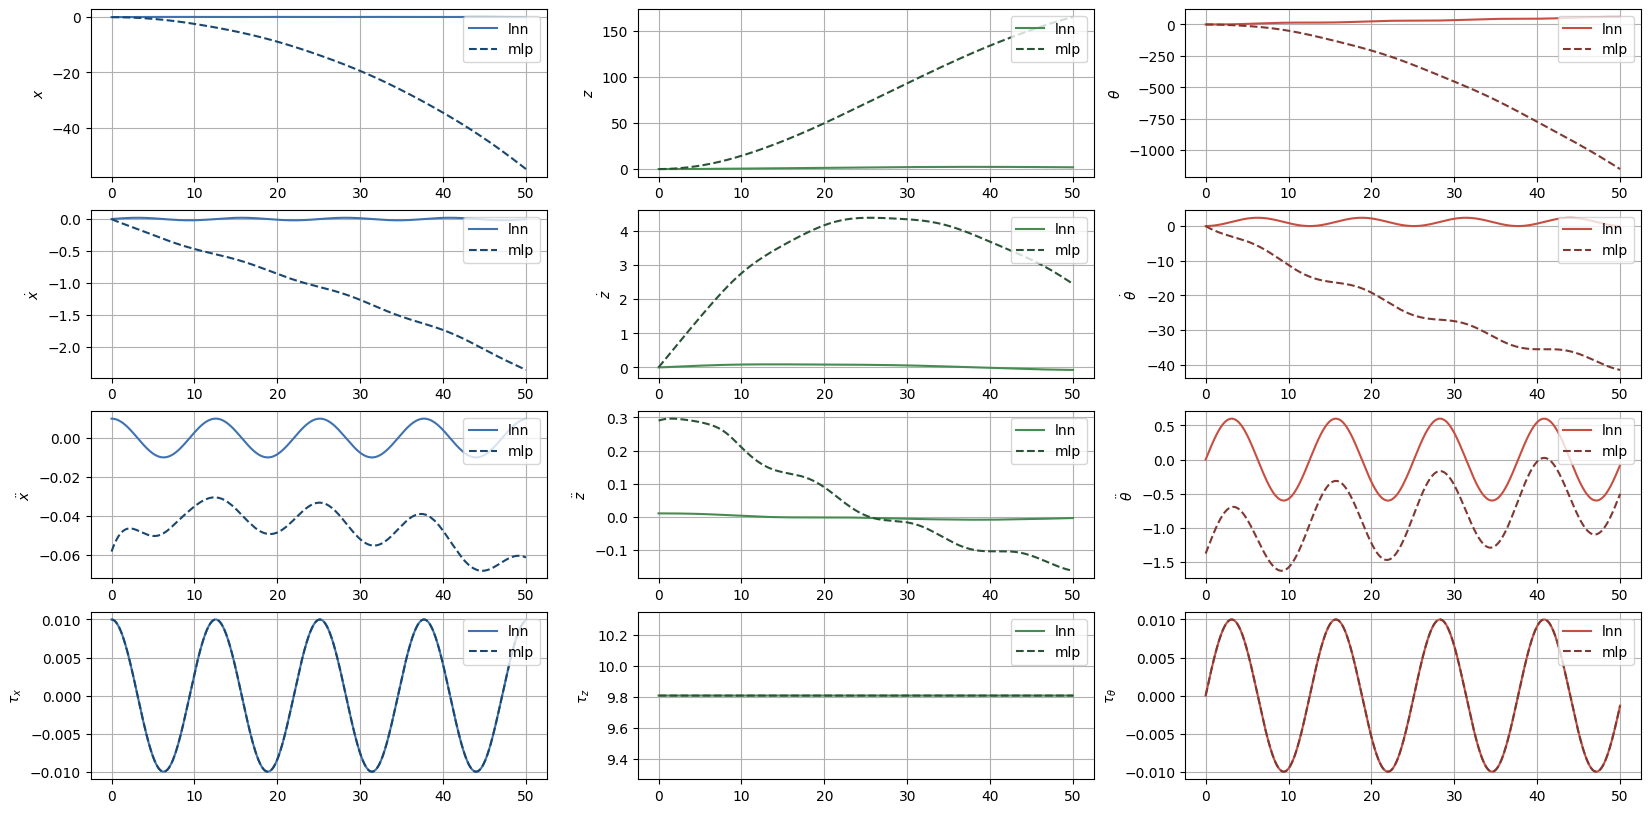

In [21]:
data_list = [lnn_nof_data, mlp_data]
# data_list = [lnn_nof_data]
data_list_names = ["lnn", "mlp"]

legends = ['x', 'z', r'\theta']
# labels = ['position', 'velocity', 'accerleration', 'force']
labels = ['', r'\dot ', r'\ddot ', r'\tau_']
lstyle = ['-', '--']
hex_colors = [
    # Blues (Light to Dark)
    '#3F72AF', 
    '#1A476F', 
    
    # Greens (Light to Dark)
    '#468B52', 
    '#2A5236', 
    
    # Reds (Light to Dark)
    '#C74F41', 
    '#7F3932'  
]

end = 5000

def plot_data(key, column, iter):
    for i, data in enumerate(data_list):
        plt.plot(data["ts"], data[key][:, column], linestyle=lstyle[i], color=hex_colors[2 * (iter % 3) + i])

plt.figure(figsize=(10*2, 5*2))
for i in range(12):
    plt.subplot(4,3,i+1)
    if i < 6:  plot_data("xs", i, i)
    elif i < 9:  plot_data("xts", i-3, i)
    else: plot_data("frcs", i-9, i)
    plt.legend(data_list_names, loc='upper right')
    plt.ylabel(rf"${labels[i//3]}{legends[i%3]}$")
    plt.grid()    


In [28]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch, Circle
from matplotlib.animation import FuncAnimation
from matplotlib.transforms import Affine2D
import matplotlib.patheffects as path_effects

def create_rectangle_animation(states, filename="rectangle_motion.gif", fps=30, dpi=100):
    """
    Create simple animation of a rectangle moving in 2D with force and torque indicators.
    
    Args:
        states: numpy array of shape (n_frames, 6)
               where each row is [x, z, theta, tau_x, tau_z, tau_theta]
        filename: output filename
        fps: frames per second
        dpi: resolution
    """
    # Setup figure and axis
    fig, ax = plt.subplots(figsize=(8, 6))

    xmin, xmax = 1.2 * np.min(states[:,0]), 1.2 * np.max(states[:,0])
    ymin, ymax = 1.2 * np.min(states[:,1]), 1.2 * np.max(states[:,1])

    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)
    ax.set_aspect('equal')
    ax.grid(True, linestyle='--', alpha=0.7)
    
    # Rectangle dimensions
    rect_width, rect_height = 0.2, 0.1
    
    # Create initial objects
    rect = Rectangle((-rect_width/2, -rect_height/2), rect_width, rect_height, 
                   color='green', alpha=0.7)
    ax.add_patch(rect)
    
    force_arrow_x = FancyArrowPatch((0, 0), (0, 0), color='red', lw=2, 
                                arrowstyle='->', mutation_scale=15)
    force_arrow_z = FancyArrowPatch((0, 0), (0, 0), color='red', lw=2, 
                                arrowstyle='->', mutation_scale=15)
    ax.add_patch(force_arrow_x)
    ax.add_patch(force_arrow_z)
    
    # For torque, we'll use a list of points and a line collection
    # Initialize with empty lists
    torque_points = []
    torque_line, = ax.plot([], [], 'b-', lw=2)
    
    # Create arrow for torque direction
    torque_arrow = FancyArrowPatch((0, 0), (0, 0), color='blue', lw=2, 
                                arrowstyle='->', mutation_scale=15)
    ax.add_patch(torque_arrow)
    
    # Text for showing state values
    state_text = ax.text(0.02, 0.95, '', transform=ax.transAxes, 
                        verticalalignment='top', fontsize=10)
    
    def init():
        """Initialize animation"""
        rect.set_xy((-rect_width/2, -rect_height/2))
        rect.set_transform(ax.transData)
        force_arrow_x.set_positions((0, 0), (0, 0))
        force_arrow_x.set_visible(False)
        force_arrow_z.set_positions((0, 0), (0, 0))
        force_arrow_z.set_visible(False)
        torque_line.set_data([], [])
        torque_arrow.set_positions((0, 0), (0, 0))
        torque_arrow.set_visible(False)
        state_text.set_text('')
        return rect, force_arrow_x, force_arrow_z, torque_line, torque_arrow, state_text
    
    def update(frame):
        print(frame, end="\r")
        """Update animation for each frame"""
        x, z, theta, force_x, force_z, torque = states[frame]
        theta_deg = np.degrees(theta)
        
        # Update rectangle position and rotation
        transform = Affine2D().rotate(theta).translate(x, z) + ax.transData
        rect.set_transform(transform)
        
        # Update force arrow
        if np.hypot(force_x, force_z) > 1e-6:
            force_scale = 0.5
            start_point = (x, z)
            end_point_x = (x + force_x * 20, z)
            end_point_z = (x, z + force_z * 0.05)
            force_arrow_x.set_positions(start_point, end_point_x)
            force_arrow_x.set_visible(True)
            force_arrow_z.set_positions(start_point, end_point_z)
            force_arrow_z.set_visible(True)
        else:
            force_arrow_x.set_visible(False)
            # force_arrow_z.set_visible(False)
        
        # Update torque visualization - 80% of a circle
        if abs(torque) > 1e-6:
            # Vary the arc radius based on torque magnitude
            radius = 0.2 + min(abs(torque) * 0.4, 0.8)
            
            # Create points along arc (80% of a circle = 288 degrees)
            if torque > 0:  # Counter-clockwise
                angles = np.linspace(0, 288 * np.pi/180, 50)
            else:  # Clockwise
                angles = np.linspace(180 * np.pi/180, -108 * np.pi/180, 50)
                
            # Generate points
            torque_x = x + radius * np.cos(angles)
            torque_y = z + radius * np.sin(angles)
            
            # Update line data
            torque_line.set_data(torque_x, torque_y)
            torque_line.set_visible(True)
            
            # Position arrow at the end of the arc
            end_angle = angles[-1]
            arrow_x = x + radius * np.cos(end_angle)
            arrow_y = z + radius * np.sin(end_angle)
            
            # Tangent direction for arrow (perpendicular to radius)
            if torque > 0:
                dx = -radius * np.sin(end_angle) * 0.3
                dy = radius * np.cos(end_angle) * 0.3
            else:
                dx = radius * np.sin(end_angle) * 0.3
                dy = -radius * np.cos(end_angle) * 0.3
            
            torque_arrow.set_positions((arrow_x, arrow_y), (arrow_x + dx, arrow_y + dy))
            torque_arrow.set_visible(True)
        else:
            torque_line.set_data([], [])
            torque_line.set_visible(False)
            torque_arrow.set_visible(False)
        
        # Update text
        state_text.set_text(f'x: {x:.2f}, z: {z:.2f}, θ: {theta_deg:.1f}°\n'
                          f'Force: ({force_x:.2f}, {force_z:.2f})\n'
                          f'Torque: {torque:.2f}')
        
        return rect, force_arrow_x, force_arrow_z, torque_line, torque_arrow, state_text
    
    # Create animation
    anim = FuncAnimation(fig, update, frames=len(states), init_func=init,
                        blit=True, interval=1000/fps)
    
    # Save as GIF
    anim.save(filename, writer='pillow', fps=fps, dpi=dpi)
    plt.close()
    print(f"Animation saved as {filename}")

# Example usage
if __name__ == "__main__":
    # Create example data - circle motion with rotation
    # n_frames = 120
    # t = np.linspace(0, 2*np.pi, n_frames)
    # x = 3 * np.cos(t)
    # z = 2 * np.sin(t)
    # theta = t
    # force_x = -np.sin(t)
    # force_z = np.cos(t)
    # torque = 0.5 * np.sin(2*t)

    x,z,theta = lnn_nof_data['xs'][::10, :3].T
    force_x, force_z, torque = lnn_nof_data['frcs'][::10, :3].T

    # x,z,theta = mlp_data['xs'][::10, :3].T 
    # force_x, force_z, torque = mlp_data['frcs'][::10, :3].T
    
    states = np.column_stack((x, z, theta, force_x, force_z, torque))
    create_rectangle_animation(states, "rectangle_motion_lnn.gif")

Animation saved as rectangle_motion_lnn.gif
